# What Follows from p = E(mx)?

### Counterexamples to the Directional Claims in Chapter 1 of Cochrane's *Asset Pricing*

**Kevin Egan** (kevin.egan@gmail.com)

This notebook is self-contained: re-running it regenerates all data, tables,
and figures. It requires only `numpy` and `matplotlib`. Chapters 1 and 2 of
the book are available free from the author's
[webpage](https://www.johnhcochrane.com/s/samplechapters-dy5d.pdf).

*References of the form* Eqn 1.2 *are to equations of Chapter 1 of *Asset Pricing*;
references of the form* Section 1.1 *are to sections of *Asset Pricing*.*

## 1. Background and motivation

Chapter 1 of Cochrane's *Asset Pricing* gives a nice derivation of
the consumption-based pricing model based on a single investor optimizing
for their own utility.

We start with the option to buy at time $t$ a random payoff $x_{t+1}$ which will
be delivered at time $t+1$.  Units of this random payoff can be purchased now
at time $t$ at a fixed price $p_t$.  The payoff $x_{t+1}$ is the entire value of
the payoff or investment, it does not include any subtraction to calculate profit
or return.  We can compute the gross return
$R_{t+1} = x_{t+1}/p_t$ as the payoff per dollar invested.

The model is built around the choice problem of a marginal investor who wants to
maximize their utility $U$ across time $t$ and $t+1$.  For a given time we measure
utility $u()$ based on the consumption $c$ at some time.  Note that the investor
can predict their consumption $c_t$ and utility $u(c_t)$ at time $t$ because all of
the values at time $t$ are fixed (including the price $p_t$ which we will get into later).
The consumption $c_{t+1}$ and utility $u_{t+1}$ at time $t+1$ are random variables because
they may depend on the payoff $x_{t+1}$ which is random.

We make some assumptions about the utility function $u()$ for a given moment in time.
From the book: *"The period utility function $u(\cdot)$ is increasing,
reflecting a desire for more consumption, and concave, reflecting the
declining marginal value of additional consumption"* (Section 1.1). We also assume
that the investor discounts future utility by a factor $\beta \in (0,1)$ because
they would rather consume now at $t$ than later at time $t+1$.
Taking this altogether we get the following:

$$
U(c_t, c_{t+1}) = u(c_t) + \beta E_t \big[ u(c_{t+1}) \big]. \tag{Section 1.1}
$$

The investor receives non-asset income (an endowment) $e_t$ today and
$e_{t+1}$ tomorrow, and $e_{t+1}$ may vary across future states. In this example
the investor can optimize their utility by trading a single asset: each unit costs
$p_t$ today and pays $x_{t+1}$ tomorrow, and the
investor may buy any quantity $\xi$. The price $p_t$ is assumed to be a
constant that will not change.

It is worth being careful about which quantities are fixed (exogenous) and which can
be changed by the investor (endogenous), because much of what follows depends on it.
Variables that are fixed: $p_t$, the endowments $e_t$ and $e_{t+1}$, the payoff
$x_{t+1}$, the discount factor $\beta$, and the utility function $u$.  Note that
$e_{t+1}$ and $x_{t+1}$ are random variables, but they are fixed in the sense that
they cannot be changed by the investor.  The only thing that the investor can decide
is the amount to purchase $\xi$. The consumption values are determined according to $\xi$
and the other fixed variables:

$$
c_t = e_t - p_t\,\xi, \qquad c_{t+1} = e_{t+1} + x_{t+1}\,\xi.
$$

The investor neither chooses $c_t$ and $c_{t+1}$ freely nor faces them as
independent random variables. Once $\xi$ is picked, both consumptions are
functions of $\xi$ alone, state by state: $c_t$ is a single number, and
$c_{t+1}$ varies across states only because the fixed $e_{t+1}$ and
$x_{t+1}$ do. Buying more $\xi$ gives up consumption today in exchange for
consumption tomorrow, state by state.

The book states its objective in terms of $c_t$ and $c_{t+1}$. We will
define a new variable $V$, not used in the book, for the investor's
objective $U$ written as a function of the single choice variable $\xi$:

$$
V(\xi) \;=\; u\big(e_t - p_t\xi\big) \;+\; \beta\, E_t\Big[u\big(e_{t+1} + x_{t+1}\xi\big)\Big],
$$

The investor chooses $\xi$ to maximize $V(\xi)$;
setting $V'(\xi) = 0$ gives the first-order condition

$$
p_t\, u'(c_t) = E_t\big[\beta u'(c_{t+1})\, x_{t+1}\big]. \tag{Eqn 1.1}
$$

with $c_t$ and $c_{t+1}$ evaluated at $\xi$. Its solution $\xi^*$ is the
quantity at which the marginal gain of the payoff equals the marginal loss
of the price. It pins down both consumptions.

Given $p_t$, the derivation stops there: it is a theory of optimal
consumption and portfolio choice. In the book's mathematical formulation
$p_t$ is a fixed constant. The investor cannot change it, and nothing in
the derivation does. The same identity is often read in reverse, as
determining the price given consumption, and several of the book's
directional sentences speak of $p_t$ as if it could change. Those sentences
are claims about a different object: the equilibrium price, determined
jointly with consumption. They require mathematics that the derivation does
not provide, namely a specified held-fixed set and a market-clearing
condition. Sections 5 and 6 below take up the two readings of this sentence
separately. Which reading is in force is a matter of the held-fixed set,
not of the equation.

Dividing Eqn 1.1 by $u'(c_t)$ gives the chapter's pricing equation,

$$
p_t = E_t\Big[\beta\, \frac{u'(c_{t+1})}{u'(c_t)}\, x_{t+1}\Big]. \tag{Eqn 1.2}
$$

Defining the **stochastic discount factor** (SDF),

$$
m_{t+1} \equiv \beta\,\frac{u'(c_{t+1})}{u'(c_t)}, \tag{Eqn 1.3}
$$

turns it into the compact form used throughout the chapter,

$$
p_t = E_t\big[m_{t+1}\, x_{t+1}\big]. \tag{Eqn 1.4}
$$

The name is literal: $m$ is a discount factor because it multiplies
tomorrow's payoff to give today's price, and it is stochastic because its
value varies with the state. It is the investor's marginal rate of
substitution between tomorrow's and today's consumption: states where
consumption is low get a high $u'(c_{t+1})$, hence a high weight $m$, so
payoffs that arrive in bad states are worth more today. The price is the
average of the state-by-state products $m\,x$.

The chapter is explicit that Eqn 1.2 is not a reduced form: price,
consumption, and payoffs are all endogenous, and the model is "stopped short
of a complete solution." The remainder of the chapter manipulates it into
familiar objects: the
risk-free rate (Eqn 1.6) and its lognormal form (Eqn
1.7), the risk-correction decomposition (Eqns 1.8–1.10), the return and
consumption-beta representations (Eqns 1.11–1.16), and the mean-variance
frontier (Eqns 1.17–1.20). Each is accompanied by a directional economic
sentence: that prices fall when payoffs covary with consumption, that
expected returns rise with consumption betas, that real rates rise with
expected consumption growth, that the upper mean-variance frontier is
"maximally risky," and so on.

**The question this notebook asks is which of those sentences are consequences
of the equations together with the chapter's stated assumptions**
(increasing, concave $u$; $\beta \in (0,1)$; price-taking) **and which
require more.** The
point is not pedantry about the mathematics. A first-order condition is an
identity that holds *at* a stationary point; it becomes a characterization of
behavior only given a second-order condition. An equilibrium identity is not a
comparative static until a held-fixed set is specified. And a covariance sign
cannot be transplanted from one pair of variables to another without an
ordering hypothesis. Two specific gaps can open between an equation and the
sentence printed next to it:

1. **Gap 1: Identity vs. comparative static.** In the investor's problem the
   consumptions are functions of $\xi$, and the price $p_t$ is assumed to
   be a constant that will not change. A statement of the form "if parameter
   $a$ moves, endogenous object $y$ moves thus" is a claim about the system
   after the change: we must solve the optimization again, the optimal $\xi$
   moves, and every function of $\xi$ moves with it. Reading the identity as
   if the right-hand side were held fixed is not logically correct, because
   many variables can change when the problem is solved again. When a
   held-fixed set *is* specified, the comparative static can be correct
   (e.g., consumption held at a level that does not depend on the price,
   as at a content point); the error is leaving it unspecified.

2. **Gap 2: Covariance sign transfer.** Several takeaways infer the sign of
   $\operatorname{cov}(u'(c_{t+1}), x)$ from the sign of
   $\operatorname{cov}(c_{t+1}, x)$. Concavity makes $u'$ decreasing, but a
   decreasing transformation does not preserve covariance signs in general;
   the transfer requires an ordering hypothesis on the joint distribution
   that is strictly stronger than positive correlation: comonotonicity
   (section 11 below).

The method throughout is not to argue but to exhibit: each claim is paired with
a fully specified small economy (two dates, three equiprobable states,
simple parameter values) in which the investor's problem is solved exactly
(analytic derivatives, the optimum found by repeatedly narrowing a
bracketing interval, the second-order condition verified, and all
consumption strictly positive in every state). The chapter's sentences are then checked against the solution under
the chapter's stated assumptions; where a sentence requires more, the
counterexamples isolate the missing hypothesis (comonotonicity, exogeneity
of consumption).

**The equations are right; the sentences sometimes are not fully supported.**
Nothing below disputes a displayed equation of the chapter. Section 3 verifies
the entire algebraic skeleton (Eqns 1.2, 1.4, 1.6, 1.9, 1.12, 1.14,
projection pricing, and the Sharpe bound of Eqn 1.17) to machine precision
at a verified interior optimum. The equations are conditional algebra and
they are correct. What varies across the sections is the status of the prose:
whether the sentence printed next to an equation is supported by that
equation alone, or needs an interpretation the chapter does not state.

**The two interpretations.** Every directional sentence below is examined
under one of two readings, and each section states which one it is testing:

- **The equilibrium interpretation.** Every quantity the sentence mentions
  (consumption, payoff, price) is understood to be the model's equilibrium
  outcome. "Given the investor's consumption choice" means "given the
  consumption choice the investor makes in equilibrium". Under this reading
  a sentence is true if it holds at the equilibrium allocation, and the
  allocation being solved jointly with the price is not an objection.
- **The comparative static interpretation.** The sentence is read as saying
  how an endogenous object (usually the price) changes when one input is
  moved by a small amount $\varepsilon$ without changing anything else. This
  reading requires a **held-fixed set**: an explicit list of the quantities
  that do not move. If moving the input in fact moves other equilibrium
  quantities, because the model must be re-solved, the reading can fail.
- **The "as stated" tag.** Sections 9–19 below tag their reading "as
  stated": the sentence is tested under the equilibrium interpretation,
  with every quantity it mentions understood as the model's outcome. Where
  a fixed-consumption evaluation is also shown, the verdict does not
  depend on the choice.

**The book's own later caveat.** Chapter 2, included in the same free
sample, concedes most of the first gap. Section 2.1 notes that the formula
can also be applied to "generate the marginal private valuation, using
pre-trade consumption, or ... value a potential, not yet traded security",
and Section 2.2 warns that "it is enormously tempting to slide into an
interpretation that E(mx) determines p" and that for such questions "one
really needs to start thinking in general equilibrium terms". The
sentences examined below are the chapter 1 sentences as the first chapter
prints them; the audit is of that prose, not of the book's full position.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

PI3 = np.ones(3) / 3.0                       # probabilities of the three states
np.set_printoptions(precision=6, suppress=True)
E = lambda a: float(np.dot(PI3, a))          # expectation over the three states
cov = lambda a, b: E(a * b) - E(a) * E(b)

def bisect(f, a, b):                         # root of f on [a, b], narrowing the interval
  fa = f(a)
  for _ in range(200):
    mid = 0.5 * (a + b)
    if fa * f(mid) <= 0: b = mid
    else: a, fa = mid, f(mid)
    if b - a < 1e-14: break
  return 0.5 * (a + b)

def solve_log(e1, x, p, beta=1.0, e_t=1.0):  # optimal trade xi* when u = ln c
  dV = lambda xi: -p/(e_t - p*xi) + beta*E(x/(e1 + x*xi))
  lo = max([-e1[s]/x[s] for s in range(3) if x[s] > 0] + [-1e9]) + 1e-9
  hi = min([-e1[s]/x[s] for s in range(3) if x[s] < 0] + [e_t/p]) - 1e-9
  return bisect(dV, lo, hi), lo, hi

def price_line(): print('-' * 74)

# --- economies and formulas reused by later sections, defined once here so that
# --- any section's demo runs on its own after this cell (skip sections freely)
rf = lambda mu, s, g: 1/(np.exp(-0.01)*0.5*(np.exp(-g*(mu+s)) + np.exp(-g*(mu-s)))) - 1
                                             # net r^f, two-point lognormal family (demos 9.1, 10.1)
e1x, Xx, Rstore = np.array([0.8, 1.0, 1.5]), np.array([0.9, 1.0, 1.2]), 1.02

def sav_rate(b, g):                          # storage economy: saving s from the FOC, then log r^f
  f = lambda s: b*np.dot(PI3, (e1x + Rstore*s)**(-g) * (1 - s)**g) * Rstore - 1
  s = bisect(f, -0.8/Rstore + 1e-9, 0.999)
  Em = b*np.dot(PI3, (e1x + Rstore*s)**(-g) * (1 - s)**g)   # = 1/R_store by the FOC
  return s, np.log(1.0/Em)

rfree = lambda b, g: -np.log(b) - np.log(np.dot(PI3, (e1x + Xx)**(-g)))  # consumption p-free log r^f

def solve_ref():                             # the log-utility equilibrium of demos 11.2, 12.1, 15.1, 18.1
  e1, x, p = np.array([0.7, 2.2, 3.6]), np.array([3., -2., 4.]), 0.9
  xi = solve_log(e1, x, p)[0]
  ct, c1 = 1 - p*xi, e1 + x*xi
  m = ct / c1; Rf = 1/E(m); R = x / p        # m = beta u'(c1)/u'(ct), log, beta = 1
  x_com = c1 - ct + 1.5                      # increasing in c1: comonotone with consumption
  m_com = ct / c1
  p_com, rn_com = E(m_com * x_com), E(x_com) * E(m_com)
  return e1, x, p, xi, ct, c1, m, Rf, R, x_com, m_com, p_com, rn_com

## 2. Different types of concave utility functions

Every directional claim in the chapter is a statement about the shape of
$u$ and $u'$. The first figure shows the two graphs for the **power
family** member $u(c) = c^{1-\gamma}/(1-\gamma)$ with $\gamma = 1$ (log,
$u = \ln c$, $u' = 1/c$) and $\gamma = 2$ ($u = -1/c$, $u' = 1/c^2$).
For $\gamma > 0$ both members are increasing and concave, the chapter's
stated assumption, and the property that makes the stationary point of
$V$ the optimum (section 3). Marginal utility $u'(c)$ is the object that
actually prices: the SDF is $m = \beta\,u'(c_{t+1})/u'(c_t)$, so each
state's payoff is weighted by how badly consumption is wanted in that
state, and for $\gamma = 2$ the weight rises steeply as $c$ falls.

**Concavity of $u$ does not say whether $u'$ is concave.** Concavity says
$u'$ is *decreasing*; it says nothing about the curvature of $u'$ itself.
The right-hand panels show that for both power laws $u'$ is **convex**
(not concave): for power utility $u''' = \gamma(\gamma+1)\,c^{-\gamma-2} >
0$ whenever $\gamma > 0$. A utility can equally well be increasing,
strictly concave, and have a **concave** $u'$: the second figure shows
$u = c - c^3/6$ (defined on $(0, \sqrt{2})$, where $u' = 1 - c^2/2 > 0$),
with $u''' = -1 < 0$. Both shapes satisfy the book's stated assumptions.
The distinction matters in section 10, where the sign of the $\sigma^2$
term of the log risk-free rate turns out to be the sign of $-u'''$: the
power family delivers one sign automatically, concavity alone does not.

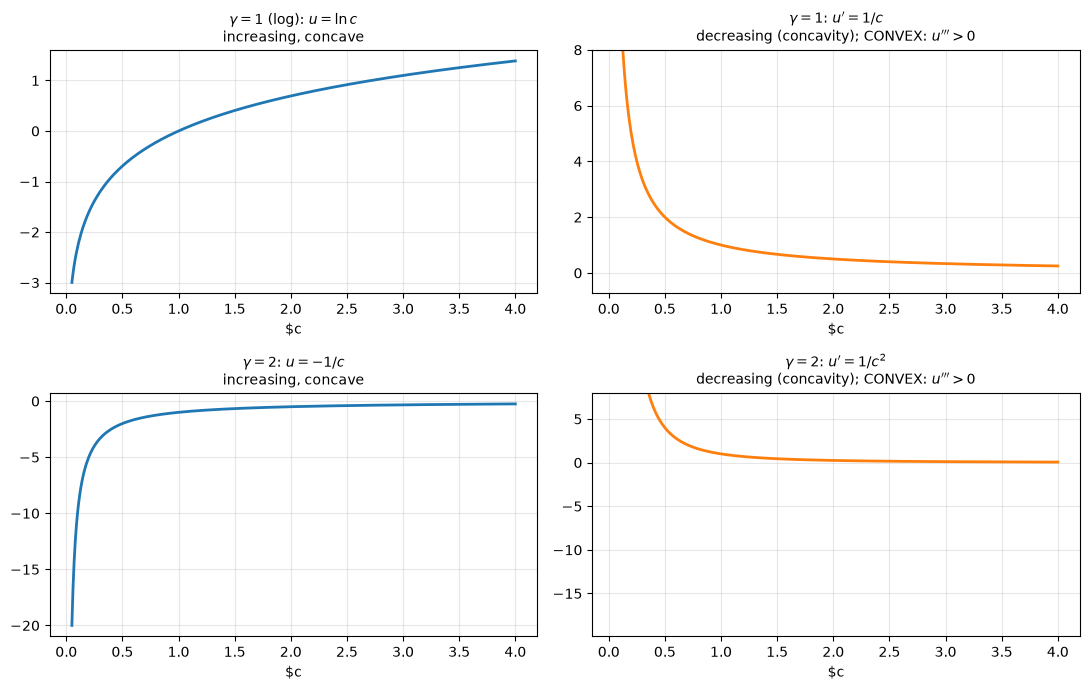

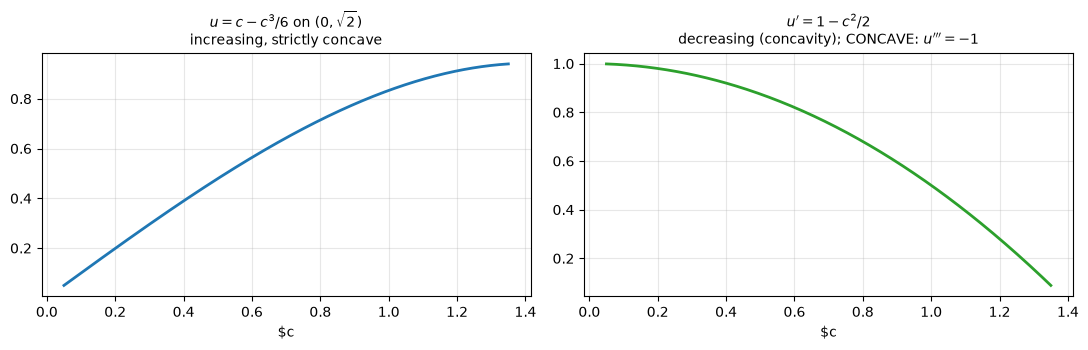

power laws (gamma = 1 log, gamma = 2): u' decreasing AND convex (u''' > 0).
u = c - c^3/6: u' decreasing but concave (u''' < 0). Both satisfy the book's
stated assumption (increasing, concave u); the curvature of u' is extra
structure that the book does not pin down. Sections below track it.


In [2]:
# u and u' for the two power laws (gamma = 1 log, gamma = 2) and the cubic u = c - c^3/6
cs = np.linspace(0.05, 4, 400)
fig, ax = plt.subplots(2, 2, figsize=(11, 7))
for a, u, t in [(ax[0, 0], np.log(cs), '$\\gamma=1$ (log): $u = \\ln c$'),
                (ax[1, 0], -1.0/cs, '$\\gamma=2$: $u = -1/c$')]:
  a.plot(cs, u, lw=2); a.set_title(t + '\nincreasing, concave', fontsize=10)
for a, u, t in [(ax[0, 1], 1.0/cs, "$\\gamma=1$: $u' = 1/c$"),
                (ax[1, 1], 1.0/cs**2, "$\\gamma=2$: $u' = 1/c^2$")]:
  a.plot(cs, u, lw=2, color='C1')
  a.set_title(t + "\ndecreasing (concavity); CONVEX: $u''' > 0$", fontsize=10)
for a in ax.flat: a.set_xlabel('$c'); a.grid(alpha=0.3)
for a in ax[:, 1]: a.set_ylim(top=8)
plt.tight_layout(); plt.show()

cs2 = np.linspace(0.05, 1.35, 400)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(cs2, cs2 - cs2**3/6, lw=2)
ax[0].set_title('$u = c - c^3/6$ on $(0,\\sqrt{2})$\nincreasing, strictly concave', fontsize=10)
ax[1].plot(cs2, 1 - cs2**2/2, lw=2, color='C2')
ax[1].set_title("$u' = 1 - c^2/2$\ndecreasing (concavity); CONCAVE: $u''' = -1$", fontsize=10)
for a in ax: a.set_xlabel('$c'); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("power laws (gamma = 1 log, gamma = 2): u' decreasing AND convex (u''' > 0).")
print("u = c - c^3/6: u' decreasing but concave (u''' < 0). Both satisfy the book's")
print("stated assumption (increasing, concave u); the curvature of u' is extra")
print("structure that the book does not pin down. Sections below track it.")

## 3. The math behind the investor's choice problem

Before any interpretation is tested, two mathematical facts. Neither is a
directional economic sentence, and neither depends on a reading: they hold
at any interior optimum, for any increasing differentiable $u$.

**Fact 1 (the FOC characterizes the choice).** The chapter states that $u$
is increasing and concave but does not spell out this derivation.
Differentiating the objective
$V(\xi) = u(e_t - p_t\xi) + \beta E_t[u(e_{t+1} + x_{t+1}\xi)]$ twice along
the budget constraints $c_t = e_t - p_t\xi$,
$c_{t+1} = e_{t+1} + x_{t+1}\xi$ gives

$$
V'(\xi) = -p_t\,u'(c_t) + \beta\, E_t\big[u'(c_{t+1})\,x_{t+1}\big],
\qquad
V''(\xi) = p_t^2\,u''(c_t) + \beta\, E_t\big[u''(c_{t+1})\,x_{t+1}^2\big].
$$

With $u$ concave ($u''\le 0$) every term is non-positive ($p_t^2>0$,
$x_{t+1}^2\ge 0$, $\beta>0$), so $V$ inherits concavity from $u$ and a
stationary point is a global maximum, unique under strictly concave $u$.
The first-order condition (FOC), $V'(\xi)=0$, characterizes the optimal
choice for the investor.

**Fact 2 (the identities).** $p = E[mx]$ and the identities of
§§1.1–1.4 hold exactly at any interior optimum. The demo below verifies
them, one row per equation, at the log-utility optimum of $\beta=0.95$,
$p=0.9$, $e_t=1$, $e_{t+1}=(1,2,3)$, $x=(0.5,1,2)$. In the projection row,
$\operatorname{proj}(x\,|\,m) = (E[mx]/E[m^2])\,m$ is the linear regression
of the payoff on the SDF: the part of $x$ perfectly correlated with $m$.

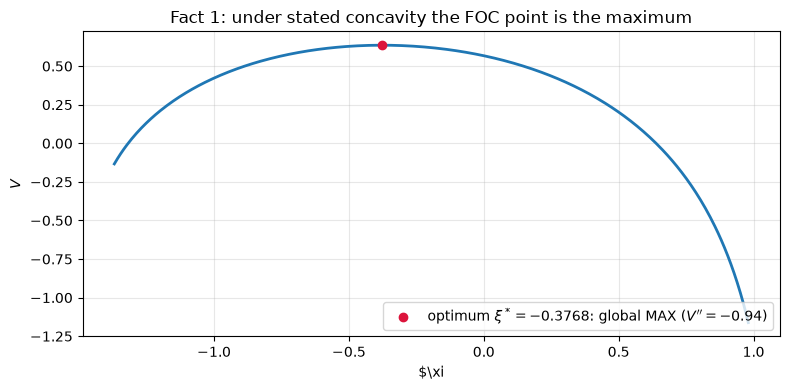

xi* = -0.376773   c_t = 1.339096   c_(t+1) = [0.811613 1.623227 2.246453]   (all > 0, V'' < 0)
Identity checks at xi* = -0.376773 (the log-utility optimum):
each row is one equation of Sections 1.1-1.4, evaluated at the optimum;
the left- and right-hand sides must agree.
--------------------------------------------------------------------------
  Eqn 1.4  p = E[mx]                   lhs= 0.90000000  rhs= 0.90000000  OK
  Eqn 1.6  Rf = 1/E[m]                 lhs= 1.02830490  rhs= 1.02830490  OK
  Eqn 1.9  p = E(x)/Rf + cov(m,x)      lhs= 0.90000000  rhs= 0.90000000  OK
  Eqn 1.12 E(R)-Rf = -Rf cov(m,R)      lhs= 0.26799139  rhs= 0.26799139  OK
  Eqn 1.14 E(R) = Rf + beta_Rm*lam_m   lhs= 1.29629630  rhs= 1.29629630  OK
  proj    p(proj(x|m)) = p(x)          lhs= 0.90000000  rhs= 0.90000000  OK
  (1.17)  Sharpe 0.386768 <= sig(m)/E(m) 0.442124: True

-> the entire algebraic skeleton of Sections 1.1-1.4 holds exactly at the interior optimum.


In [3]:
# Facts 1 and 2: solve the log-utility optimum and verify every identity of SS1.1-1.4
e1, x, beta, p = np.array([1., 2., 3.]), np.array([0.5, 1., 2.]), 0.95, 0.9
xi, lo, hi = solve_log(e1, x, p, beta)
ct, c1 = 1 - p*xi, e1 + x*xi
Vpp = -p**2/ct**2 - beta*E(x**2/c1**2)       # V'' at xi* for u = ln c

zs = np.linspace(lo + 0.05*(hi - lo), hi - 0.05*(hi - lo), 400)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(zs, [np.log(1 - p*z) + beta*E(np.log(e1 + x*z)) for z in zs], lw=2)
ax.scatter([xi], [np.log(ct) + beta*E(np.log(c1))], color='crimson', zorder=5,
           label=f'optimum $\\xi^*={xi:.4f}$: global MAX ($V\'\'={Vpp:.2f}$)')
ax.set_xlabel('$\\xi'); ax.set_ylabel('$V$'); ax.legend(loc='lower right')
ax.set_title('Fact 1: under stated concavity the FOC point is the maximum')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f"xi* = {xi:.6f}   c_t = {ct:.6f}   c_(t+1) = {c1}   (all > 0, V'' < 0)")

# the identities, one row per equation, at this optimum
m = beta * ct / c1; Rf = 1/E(m); R = x / p
proj = (E(m*x)/E(m*m)) * m
rows = [
  ('Eqn 1.4  p = E[mx]',                 p,            E(m*x)),
  ('Eqn 1.6  Rf = 1/E[m]',               Rf,           1/E(m)),
  ('Eqn 1.9  p = E(x)/Rf + cov(m,x)',    p,            E(x)/Rf + cov(m, x)),
  ('Eqn 1.12 E(R)-Rf = -Rf cov(m,R)',    E(R)-Rf,      -Rf*cov(m, R)),
  ('Eqn 1.14 E(R) = Rf + beta_Rm*lam_m', E(R),         Rf + cov(R, m)/cov(m, m)*(-cov(m, m)/E(m))),
  ('proj    p(proj(x|m)) = p(x)',        E(m*proj),    E(m*x)),
]
print(f"Identity checks at xi* = {xi:.6f} (the log-utility optimum):")
print("each row is one equation of Sections 1.1-1.4, evaluated at the optimum;")
print("the left- and right-hand sides must agree.")
price_line()
for name, lhs, rhs in rows:
  print(f"  {name:<36s} lhs={lhs: .8f}  rhs={rhs: .8f}  {'OK' if abs(lhs-rhs) < 1e-8*max(1,abs(lhs)) else 'MISMATCH'}")
print(f"  (1.17)  Sharpe {abs(E(R)-Rf)/np.sqrt(cov(R,R)):.6f} <= sig(m)/E(m) "
      f"{np.sqrt(cov(m,m))/E(m):.6f}: {abs(E(R)-Rf)/np.sqrt(cov(R,R)) <= np.sqrt(cov(m,m))/E(m)}")
print("\n-> the entire algebraic skeleton of Sections 1.1-1.4 holds exactly at the interior optimum.")

## 4. Summary of Examined Statements

The table gives the map of what follows: each examined sentence of the
chapter (sections 5–19 below), the reading under test, and the conclusion.
Sections 5 and 6 and the pair 7–8 test the same sentence under the two
interpretations defined in section 1; sections 9–19 carry the "as stated"
tag defined there. Where a directional word has a weak reading ("lowered"
as "not raised", "higher" as "at least as high", "increase" as "weakly
increasing"), the verdict defeats the weak reading too; each affected
section says so in an aside.

Not examined: the equity-premium arithmetic ("a risk-aversion coefficient
of 50!", §1.4), a claim about data rather than a directional sentence of
the model; the random-walk and martingale sentences (§1.4), whose
conditional moments need a different apparatus; and the end-of-chapter
problems. Section 11's scope remark covers the continuous-time sentences
(§1.5).

| section | sentence (chapter ref) | reading | conclusion |
|---|---|---|---|
| 5 | "Given the payoff $x_{t+1}$ and given the investor's consumption choice $c_t$, $c_{t+1}$, [Eqn 1.2] tells you what market price $p_t$ to expect" (§1.1) | equilibrium | true; the price is a fixed point solved jointly with the allocation |
| 6 | "Given the payoff $x_{t+1}$ and given the investor's consumption choice $c_t$, $c_{t+1}$, [Eqn 1.2] tells you what market price $p_t$ to expect" (§1.1) | comparative static | false; only the equilibrium evaluation returns the market price (Demo 6.2) |
| 7 | "Real interest rates are high when people are impatient, i.e. when $\beta$ is low" (§1.4, p. 13) | equilibrium | false; requires the additional assumption of no trading choice: with any endogenous saving margin the rate is pinned for every $\beta$ (Demo 7.1) |
| 8 | "Real interest rates are high when people are impatient, i.e. when $\beta$ is low" (§1.4, p. 13) | comparative static | true under the chapter's own held-fixed set (consumption path given, p. 13): the rate responds to $\delta$ one for one (Demo 8.1) |
| 9 | "Real interest rates are high when consumption growth is high" (§1.4, p. 13) | as stated | true; no additional assumptions needed |
| 9 | "Real interest rates are more sensitive to consumption growth if the power parameter $\gamma$ is large" (§1.4) | as stated | true; no additional assumptions needed (the growth slope is exactly $\gamma$, Demo 9.1) |
| 10 | "The new $\sigma^2$ term captures precautionary savings" (§1.4, p. 14) | as stated | true as stated (the chapter derives it inside the power family, where $u''' > 0$ always holds); the reading does not extend to all concave $u$, as the chapter itself notes (Demo 10.2) |
| 11 | "An asset's price is lowered if its payoff covaries positively with consumption" (§1.4, Eqn 1.10) | as stated | false; requires additional assumptions, such as comonotonicity between payoff and consumption (Demos 11.1 and 11.2); the weak reading "not raised" fails too |
| 11 | "An asset whose payoff covaries positively with the discount factor has its price raised and vice versa" (§1.4, Eqn 1.9) | as stated | true; no additional assumptions needed (sibling B of Demo 11.1) |
| 12 | "Assets whose returns covary positively with consumption make consumption more volatile, and so must promise higher expected returns to induce investors to hold them" (§1.4, Eqns 1.12–1.13) | as stated | false; requires additional assumptions, such as comonotonicity between return and consumption (Demo 12.1); the weak reading "at least the risk-free rate" fails too |
| 13 | "Idiosyncratic risk, uncorrelated with the discount factor, generates no premium" (§1.4) | as stated | true; no additional assumptions needed |
| 14 | "Risk corrections to asset prices should be driven by the covariance of asset payoffs with marginal utility and hence by the covariance of asset payoffs with consumption" (chapter introduction, p. 5) | as stated | false; the "hence" requires additional assumptions, such as comonotonicity between payoff and consumption (section 11); Demo 14.1 shows $\operatorname{cov}(c_{t+1},x) = 0$ with a positive risk correction |
| 15 | "Expected returns should increase linearly with their betas on consumption growth itself" (§1.4, Eqn 1.16) | as stated | false; requires additional assumptions, such as comonotonicity between return and consumption (Demo 15.1); the weak reading "weakly increasing" fails too |
| 16 | upper-frontier returns "are 'maximally risky' and thus get the highest expected returns" (§1.4, Eqns 1.17–1.18) | as stated | true; no additional assumptions needed (at their volatility level; Demo 18.1) |
| 17 | upper-frontier returns are "perfectly negatively correlated with the discount factor and hence positively correlated with consumption" (§1.4, Eqns 1.17–1.18) | as stated | true; no additional assumptions needed (Demo 18.1) |
| 18 | "The slope of the mean-standard deviation frontier is higher if the economy is riskier—if consumption is more volatile—or if investors are more risk averse" (§1.4, Eqns 1.19–1.20) | as stated | true; no additional assumptions needed (exact in the two-point family: Demo 18.1) |
| 19 | "Assets whose dividend streams covary negatively with marginal utility, and positively with consumption, have lower prices" (§1.4, p. 27) | as stated | true; no additional assumptions needed (the premise names the marginal-utility covariance) |

## 5. "Given the payoff $x_{t+1}$ and given the investor's consumption choice $c_t$, $c_{t+1}$, [Eqn 1.2] tells you what market price $p_t$ to expect" (§1.1) — the equilibrium interpretation

**The reading under test.** The equilibrium interpretation, the reading
most favorable to the sentence: every quantity in the sentence is an
equilibrium value. The consumption choice is the one the investor actually
makes when the market clears, and the price is the one at which it clears.
The sentence turns out to be true, but proving it takes machinery the
chapter's derivation does not provide, because the derivation sets $p_t$
as a given constant, not an outcome.

**Verdict:** true under this reading, once pricing is grounded in market
clearing (Demo 5.1); the price is then a fixed point solved jointly with the
allocation.

**Math: grounding the price in market clearing.** To make the price
reading a theorem you must replace the price-taking FOC with a
**market-clearing condition**, the requirement that desired trades net to
zero (what one agent buys, another sells). That is the only rigorous
sense in which $p_t$ is "a variable"; there is no optimizer whose choice
variable is the price. The cleared price $p^*$ is a **fixed point**: an
equation in which the unknown price appears on both sides and must be
solved until consistent.

**The content point.** Let the investor own $\bar s$ shares of a claim
paying $x_{t+1}$ (plus endowment $(e_t, e_{t+1})$), and let him trade at
price $p$, choosing $\xi$ to hold $\bar s + \xi$ shares. His objective,
written $W$ because he starts from the inherited shares, is

$$
W(\xi) \;=\; u\big(e_t - p\,\xi\big) \;+\; \beta\, E_t\Big[u\big(e_{t+1} + (\bar s + \xi)\,x_{t+1}\big)\Big].
$$

The **content price** $p^*$ is the only price at which he contently holds
the supply, i.e. at which his optimal trade is $\xi^* = 0$:

$$
p^* = E\Big[\beta\,\frac{u'(e_{t+1} + \bar s\,x_{t+1})}{u'(e_t)}\; x_{t+1}\Big] = E[m\,x],
$$

with $m$ evaluated at the **fixed consumption**
$(e_t,\ e_{t+1} + \bar s\,x)$, which contains no $p$. Differentiating $W$
and evaluating at $\xi = 0$:
$dW/d\xi(0) = -p\,u'(e_t) + \beta E[u'(e_{t+1}+\bar s x)\,x]
= -u'(e_t)\,(p - p^*)$, zero iff $p = p^*$. The pricing step uses no
curvature assumption; that $\xi^* = 0$ is the optimum does (Fact 1 of
section 3).

**The hidden-$p$ problem, and why it vanishes here.** Eqn 1.2 looks like a
formula for the price, but the price hides inside its own right-hand side:
today's consumption is $c_t(\xi) = e_t - p\,\xi$, so the marginal utility
$u'(c_t)$, and hence $m$, depends on $p$. Read as "$p = E[mx]$", the
equation is therefore not a formula but an implicit equation, and it is
well defined only relative to a held-fixed set of consumptions (Gap 1).
Here, and only here, the problem vanishes: the agent who contently holds
the supply trades nothing, $\xi^* = 0$, so his consumption is
$(e_t,\ e_{t+1} + \bar s\,x)$, which contains no $p$. The evaluation point
of $m$ is exogenous, and $p^* = E[mx]$ is a genuine formula.

**Demo 5.1: the demand curve crosses zero exactly at $p^*$.** The graph
below plots the investor's optimal trade $\xi^*(p)$ against the offered
price: he sells (negative $\xi^*$) when the price is high, buys (positive
$\xi^*$) when it is low, and crosses zero exactly at $p^* = E[mx]$ with
$m$ at the fixed, $p$-free consumption.

content price (log u): p* = 0.318854
verify dW/dxi(0) = -u'(e_t)(p - p*): 0.00e+00


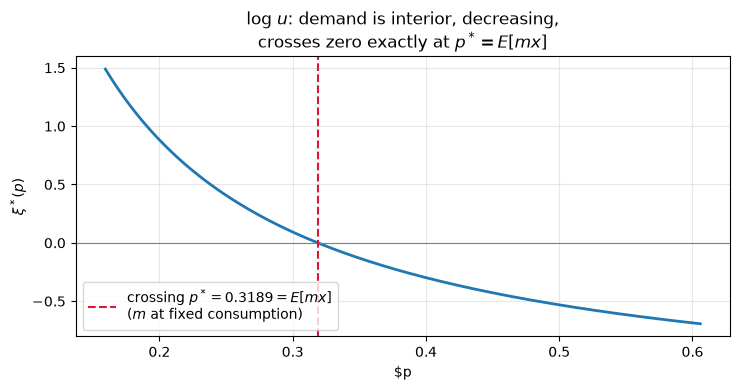

log demand: xi*(0.8p*) =  0.3697 (>0 buys), xi*(p*) = -3.34e-15, xi*(1.2p*) = -0.2452 (<0 sells)
-> the price reading of (1.2) is a THEOREM under market clearing: the content
   condition is -u'(e_t)(p - p*) = 0, linear in p, with m at p-free consumption.


In [4]:
# Demo 5.1 (content price): the agent owns s_bar = 1 share and trades at price p;
# at the content point xi* = 0 consumption is (e_t, e_1 + x): no p anywhere.
e_t, e1, x, beta = 1.0, np.array([0.8, 1.0, 1.5]), np.array([0.5, 0.7, 0.4]), 0.95
p_star = beta * e_t * E(x / (e1 + x))         # p* = E[m x], m at the fixed consumption
dW = lambda p, xi: -p/(e_t - p*xi) + beta*E(x/(e1 + (1 + xi)*x))   # dW/dxi at holding xi
dem = lambda p: bisect(lambda xi: dW(p, xi), -1 - (e1/x).min() + 1e-9, e_t/p - 1e-9)

print(f"content price (log u): p* = {p_star:.6f}")
print(f"verify dW/dxi(0) = -u'(e_t)(p - p*): {dW(p_star, 0.0):.2e}")

grid = np.linspace(0.5*p_star, 1.9*p_star, 300)
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(grid, [dem(q) for q in grid], lw=2)
ax.axhline(0, color='gray', lw=0.8)
ax.axvline(p_star, color='crimson', ls='--',
           label=f'crossing $p^*={p_star:.4f}=E[mx]$\n($m$ at fixed consumption)')
ax.set_title('log $u$: demand is interior, decreasing,\ncrosses zero exactly at $p^*=E[mx]$')
ax.set_xlabel('$p'); ax.set_ylabel('$\\xi^*(p)$'); ax.legend(loc='lower left'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"log demand: xi*(0.8p*) = {dem(0.8*p_star): .4f} (>0 buys), "
      f"xi*(p*) = {dem(p_star): .2e}, xi*(1.2p*) = {dem(1.2*p_star): .4f} (<0 sells)")
print("-> the price reading of (1.2) is a THEOREM under market clearing: the content")
print("   condition is -u'(e_t)(p - p*) = 0, linear in p, with m at p-free consumption.")

**Conclusion.** True. At the content
point the proof is one line (Demo 5.1: the clearing condition is
$-u'(e_t)(p - p^*) = 0$, linear in $p$, with $m$ at the fixed, $p$-free
consumption), so the sentence holds with the consumption choice the
investor actually makes when the market clears. One restriction of the
reading is that "given the consumption choice" is not a free input: the
allocation is
an outcome, solved jointly with the price. Section 6 tests the same
sentence as a comparative static, with the inputs moved by hand.

## 6. "Given the payoff $x_{t+1}$ and given the investor's consumption choice $c_t$, $c_{t+1}$, [Eqn 1.2] tells you what market price $p_t$ to expect" (§1.1) — the comparative static interpretation

**The reading under test.** Treat "given the investor's consumption
choice" as a free input: the idea that you can move the consumption values
(or the traded amount $\xi$) by a small $\varepsilon$ without changing
anything else, and Eqn 1.2 will still tell you the market price. Under
this reading the sentence describes a function from consumption choices to
prices. This section tests that reading.

**Verdict:** false; only the equilibrium evaluation returns the market
price, and every $\varepsilon$-move of the input gives a different answer
(Demo 6.2).

**Demo 6.1: the benchmark economy, away from the content point.** At the
content point of section 5 the investor's optimal trade was zero, so his
consumption contained no $p$; here the agents hold nonzero positions, so
their consumptions move with the price. Agent A is endowed with $e^A_1 = (0.9, 1.0, 1.1)$ and
agent B with $e^B_1 = (1.1, 0.9, 1.0)$: A is comparatively poor in state 1
and rich in state 3, B close to the reverse. The claim pays
$x = (0.3, 0, -0.3)$: it delivers $0.3$ in state 1 and *takes* $0.3$ away
in state 3, so holding it moves consumption from good states to bad. The
claim is in **zero net supply**: nobody owns it, it exists only as
offsetting positions, A's purchase is exactly B's sale
($\xi_A + \xi_B = 0$), like a bet between the two of them. Solving the two
optimization problems jointly for a price at which the market clears: the
printout reports the cleared price $p^*$, A's purchase $\xi^*$ (B sells
them), and both agents' resulting consumption. Both agents' SDFs,
evaluated at the post-trade (equilibrium) consumption, price the claim at
exactly $p^*$: the equilibrium interpretation survives away from the
content point. This solved economy is the benchmark that Demo 6.2 then
perturbs.

In [5]:
# Demo 6.1 (two agents, zero-net-supply bet): a fixed point, not a formula.
# Agent i buys xi_i: c^i_t = 1 - p xi_i, c^i_1 = e^i_1 + x xi_i; clearing xi_A + xi_B = 0.
eA1, eB1 = np.array([0.9, 1.0, 1.1]), np.array([1.1, 0.9, 1.0])
xb, beta2 = np.array([0.3, 0.0, -0.3]), 0.95
def dem(p, e1):
  dW = lambda xi: -p/(1 - p*xi) + beta2*E(xb/(e1 + xb*xi))
  return bisect(dW, max([-e1[s]/xb[s] for s in range(3) if xb[s] > 0] + [-1e9]) + 1e-9,
                     min([-e1[s]/xb[s] for s in range(3) if xb[s] < 0] + [1/p]) - 1e-9)
p_star = bisect(lambda p: dem(p, eA1) + dem(p, eB1), 0.002, 0.6)
xi_star = dem(p_star, eA1)
cA_t, cA1 = 1 - p_star*xi_star, eA1 + xb*xi_star
cB_t, cB1 = 1 + p_star*xi_star, eB1 - xb*xi_star
mA, mB = beta2*cA_t/cA1, beta2*cB_t/cB1

price_line()
print(f"equilibrium fixed point: p* = {p_star:.6f},  xi_A* = {xi_star:.6f},  xi_B* = {-xi_star:.6f}")
print(f"consumption A: ({cA_t:.6f}, {np.round(cA1, 6)})   B: ({cB_t:.6f}, {np.round(cB1, 6)})   all > 0")
print(f"aggregate c1 = {np.round(cA1 + cB1, 6)} = endowment sum (transfers net out)")
price_line()
print(f"{'evaluation point':<26s} {'E[m_A x]':>10s} {'E[m_B x]':>10s} {'p*':>10s}")
print(f"{'equilibrium allocation':<26s} {E(mA*xb):>10.6f} {E(mB*xb):>10.6f} {p_star:>10.6f}"
      f"   <- both SDFs price the claim")
print("-> away from the content point the price is a FIXED POINT, solved jointly with")
print("   the allocation; at the solved allocation both SDFs agree on the market price.")

--------------------------------------------------------------------------
equilibrium fixed point: p* = 0.004521,  xi_A* = 0.253965,  xi_B* = -0.253965
consumption A: (0.998852, [0.976189 1.       1.023811])   B: (1.001148, [1.023811 0.9      1.076189])   all > 0
aggregate c1 = [2.  1.9 2.1] = endowment sum (transfers net out)
--------------------------------------------------------------------------
evaluation point             E[m_A x]   E[m_B x]         p*
equilibrium allocation       0.004521   0.004521   0.004521   <- both SDFs price the claim
-> away from the content point the price is a FIXED POINT, solved jointly with
   the allocation; at the solved allocation both SDFs agree on the market price.


**Demo 6.2: move the input by $\varepsilon$, hold everything else fixed.**
Agent A's position is moved by $\varepsilon = \pm 0.01$ around its
equilibrium value $\xi^*$, with the price held at $p^*$ and agent B's
position unchanged, and Eqn 1.2 is evaluated on A's moved consumption. The
printout also prices the claim at the no-trade consumption (values
containing only the endowments, with no traded amount $\xi$), and at the
allocation a **planner** would choose. A planner is a single decision
maker who chooses both agents' consumption directly instead of letting
them trade; a **complete market** is one in which every
**state-contingent claim** (a claim that pays 1 in one state and 0 in the
others) can be traded, so consumption can be reallocated state by state.
With complete markets the planner's allocation is also the market
equilibrium (the first welfare theorem), and with these agents (equal
discount factors, log utility) the planner gives both agents half of
aggregate consumption in every state.

In [6]:
# Demo 6.2 (comparative static test): move agent A's holding by eps with everything
# else fixed, and evaluate Eqn 1.2 on the moved consumption.
eps = 0.01
ex = lambda xi, e1: beta2 * (1 - p_star*xi) * E(xb / (e1 + xb*xi))  # E[m x] at holding xi
cm = beta2 * E(2 * xb / (eA1 + eB1))   # planner (complete markets, equal split, c_t = 1)

price_line()
print(f"the actual market price (Demo 6.1): p* = {p_star:.6f}")
print(f"{'evaluation of E[m x]':<42s} {'agent A':>10s} {'agent B':>10s}")
print(f"{'at the equilibrium (clears; both agree)':<42s} "
      f"{ex(xi_star, eA1):>10.6f} {ex(-xi_star, eB1):>10.6f}   <- = p*: ONE price")
print(f"{'move A by eps=+0.01, all else fixed':<42s} "
      f"{ex(xi_star + eps, eA1):>10.6f} {ex(-xi_star, eB1):>10.6f}   <- A moved, B did not: two prices, no clearing")
print(f"{'move A by eps=-0.01, all else fixed':<42s} "
      f"{ex(xi_star - eps, eA1):>10.6f} {ex(-xi_star, eB1):>10.6f}   <- same failure, other direction")
print(f"{'no trade (only e_t, e_1; eps = -xi*)':<42s} "
      f"{ex(0.0, eA1):>10.6f} {ex(0.0, eB1):>10.6f}   <- both wrong, one wrong sign")
print(f"{'planner allocation (complete markets)':<42s} "
      f"{cm:>10.6f} {cm:>10.6f}   <- also an equilibrium, also not p*")
print("-> only the equilibrium evaluation returns the market price. Every epsilon-move of")
print("   the 'input' changes what Eqn 1.2 reports, and no single price survives.")

--------------------------------------------------------------------------
the actual market price (Demo 6.1): p* = 0.004521
evaluation of E[m x]                          agent A    agent B
at the equilibrium (clears; both agree)      0.004521   0.004521   <- = p*: ONE price
move A by eps=+0.01, all else fixed          0.003951   0.004521   <- A moved, B did not: two prices, no clearing
move A by eps=-0.01, all else fixed          0.005092   0.004521   <- same failure, other direction
no trade (only e_t, e_1; eps = -xi*)         0.019192  -0.008636   <- both wrong, one wrong sign
planner allocation (complete markets)        0.004524   0.004524   <- also an equilibrium, also not p*
-> only the equilibrium evaluation returns the market price. Every epsilon-move of
   the 'input' changes what Eqn 1.2 reports, and no single price survives.


**Intuition.** The $\varepsilon$-moves fail because consumption is not an
input that can be wiggled independently. It is
$c_t = e_t - p\xi$ and $c_{t+1} = e_{t+1} + x\xi$: move $\xi$ and
consumption moves with it, state by state, and the marginal-utility
weights $m$ move with consumption. The "held everything else fixed" set
turns out to be empty: there is nothing else. And the moved holding does
not clear the market either (A now wants to trade a net amount
$\pm\varepsilon$ that no one is on the other side of), so the moved
consumption is not the consumption of any market situation. The planner
row shows a second failure: even a *legitimate* equilibrium allocation
does not pin the price down, because which allocation is equilibrium
depends on which claims can be traded. The contrast with section 5 is
exact: under the equilibrium interpretation the "given" consumption is the
solved, market-clearing allocation, and the sentence holds; under the
comparative static interpretation the allocation is treated as movable
while the rest of the model stands still, and the sentence fails. This is
Gap 1: the held-fixed set has to be specified, and here it cannot be.

## 7. "Real interest rates are high when people are impatient, i.e. when $\beta$ is low" (§1.4, p. 13) — the equilibrium interpretation

**The reading under test.** The equilibrium interpretation, the reading
most favorable to the sentence: every quantity is an equilibrium value,
and $\beta$ is a preference parameter of the model. Moving $\beta$ means
re-solving the economy: saving, consumption, and the rate are all
outcomes. The chapter's boxed summary reads "Real interest rates are high
when people are impatient ($\delta$), when expected consumption growth is
high (intertemporal substitution), or when risk is low (precautionary
saving)" (p. 13), and its derivation states effect 1 verbatim: "Real
interest rates are high when people are impatient, i.e. when $\beta$ is
low. If everyone wants to consume now, it takes a high interest rate to
convince them to save" (p. 13). This section tests that sentence.

**Verdict:** false as stated; it requires the additional assumption of no
trading choice through which $\beta$ can move consumption. With any
endogenous saving margin, the saving first-order condition pins
$E[m] = 1/R_{store}$, so the rate is the same for every $\beta$ (Demo
7.1): impatience moves saving and asset prices, not the rate. The weak
reading "not lower when more impatient" holds vacuously here, since the
rate is constant in $\beta$; what fails is the claimed effect, that
impatience raises the rate.

**Math.** The chapter derives the sentence from
$R^f = \beta^{-1}(c_{t+1}/c_t)^{\gamma}$ with the consumption path held
fixed (its deterministic case, p. 13), so the rate rises exactly with
$\delta = -\ln\beta$. Whether consumption moves when $\beta$ moves is
Gap 1: the held-fixed set has to be specified, and the chapter does not
specify it. **Demo 7.1: one endogenous saving margin pins the rate.** The
agent stores consumption at gross return $R_{store} = 1.02$: storing $s$
today returns $R_{store}\,s$ tomorrow, so $c_{t+1} = e_{t+1} +
R_{store}\,s$ and $c_t = e_t - s$. The storage first-order condition,
$E[\beta\,u'(c_{t+1})/u'(c_t)] \times R_{store} = 1$, pins
$E[m] = 1/R_{store}$ exactly, so $R^f = R_{store} = 1.02$ whatever
$\beta$ is. The figure plots $r^f$ against $\beta$ for the storage
economy and for the consumption-$p$-free economy of section 8; the
printout lowers $\beta$ from $0.96$ to $0.48$ and reports the rate and
the saving that re-solves.

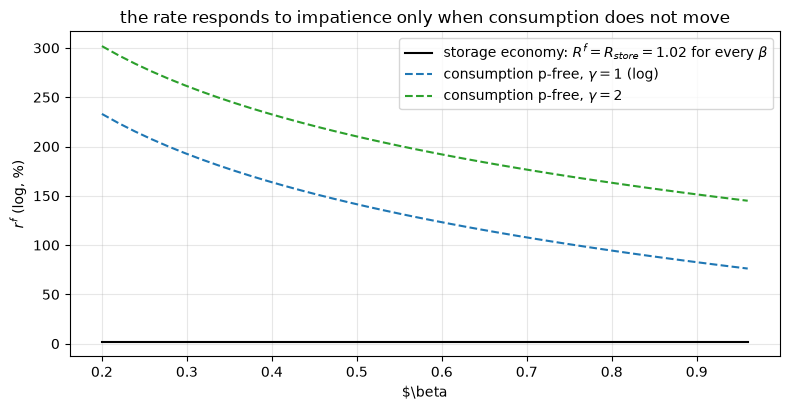

--------------------------------------------------------------------------
gamma=2: beta 0.96->0.48:  saving -0.004448 -> -0.164959   r^f 1.9803% -> 1.9803%   (pinned: ln(R_store) = 1.9803%)
log   : beta 0.96->0.48:  saving -0.023942 -> -0.337228   r^f 1.9803% -> 1.9803%   (pinned: ln(R_store) = 1.9803%)
-> (false as stated): impatience is absorbed by saving; the rate does not move.


In [7]:
# Demo 7.1 (endogenous saving margin): the storage FOC pins E[m] = 1/R_store,
# so r^f is the same for every beta: impatience moves saving, not the rate.
# (sav_rate, rfree, Rstore: storage economy from the setup cell.)
betas = np.linspace(0.2, 0.96, 40)

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(betas, [100 * np.log(Rstore)] * len(betas), '-', color='k',
        label=f'storage economy: $R^f = R_{{store}} = {Rstore}$ for every $\\beta$')
for g, col in [(1.0, 'C0'), (2.0, 'C2')]:
  ax.plot(betas, [100 * rfree(b, g) for b in betas], '--', color=col,
          label=f'consumption p-free, $\\gamma={g:.0f}$' + (' (log)' if g == 1 else ''))
ax.set_xlabel('$\\beta'); ax.set_ylabel('$r^f$ (log, %)')
ax.set_title("the rate responds to impatience only when consumption does not move")
ax.grid(alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()

price_line()
for g, glab in [(2.0, 'gamma=2'), (1.0, 'log   ')]:
  s1, r1 = sav_rate(0.96, g); s2, r2 = sav_rate(0.48, g)
  print(f"{glab}: beta 0.96->0.48:  saving {s1: .6f} -> {s2: .6f}   "
        f"r^f {r1*100:.4f}% -> {r2*100:.4f}%   (pinned: ln(R_store) = {np.log(Rstore)*100:.4f}%)")
print("-> (false as stated): impatience is absorbed by saving; the rate does not move.")

**Intuition.** What fails is the hidden premise of the sentence, that
consumption does not move when $\beta$ moves: lowering $\beta$ shifts
saving (the printout shows $s$ moving), which reshapes $c_{t+1}$ and hence
$m$, but the saving first-order condition restores $E[m] = 1/R_{store}$
exactly, so the rate does not move at all. Impatience is absorbed by
saving. This is Gap 1 again: the held-fixed set has to be specified, and
with saving endogenous it cannot contain consumption.

**Conclusion.** As stated, false: with any endogenous saving margin the
rate does not respond to impatience (Demo 7.1: $R^f$ pinned at
$R_{store} = 1.02$ for every $\beta$). The rate responds only when
consumption is $p$-free, the additional assumption that section 8 grants
and that the chapter's derivation uses without stating.

## 8. "Real interest rates are high when people are impatient, i.e. when $\beta$ is low" (§1.4, p. 13) — the comparative static interpretation

**The reading under test.** The comparative static reading of section 7's
sentence: move $\beta$ and hold everything else fixed, consumption
included. The held-fixed set has to be stated, and it can be: consumption
$p$-free (no trading margin through which $\beta$ moves it), as at the
content point of section 5 ($\xi^* = 0$) or with payoff zero.

**Verdict:** true under this reading, exactly: with consumption
$p$-free, $R^f = u'(c_t)/(\beta\,E[u'(c_{t+1})])$, so the log rate rises
one for one with $\delta = -\ln\beta$, for any $u$ (Demo 8.1). This is
the chapter's own derivation (p. 13): its formula
$R^f = \beta^{-1}(c_{t+1}/c_t)^{\gamma}$ holds the consumption path fixed
by construction. The held-fixed set is the additional assumption; the
chapter uses it without stating it, and section 7 shows what happens
without it.

**Math.** At the content point the investor holds $\bar s = 1$ inherited
share of the claim and optimally trades $\xi^* = 0$, so consumption is
$(e_t,\ e_{t+1} + \bar s\,x_{t+1})$: it contains no $p$ and no $\beta$.
With $c_t = 1$,

$$
R^f = \frac{1}{\beta\,E\big[(e_{t+1} + \bar s\,x_{t+1})^{-\gamma}\big]},
$$

exactly proportional to $1/\beta$: halving $\beta$ doubles $R^f$, for any
curvature. **Demo 8.1** prices the rate at $\beta = 0.96$ and
$\beta = 0.48$ and reports the ratio and the log-rate difference.

In [8]:
# Demo 8.1 (consumption p-free): at the content point of section 5 (xi* = 0,
# inherited holding s_bar = 1) consumption is (1, e1 + x): no p and no beta.
# Then R^f = u'(c_t)/(beta E[u'(c_1)]) is exactly proportional to 1/beta.
price_line()
for g, glab in [(2, 'gamma=2'), (1, 'log   ')]:
  R1, R2 = np.exp(rfree(0.96, g)), np.exp(rfree(0.48, g))
  print(f"{glab}: beta 0.96->0.48:  R^f {R1:.6f} -> {R2:.6f}   ratio = {R2/R1:.6f}   (exactly 2)")
  print(f"          log r^f {rfree(0.96,g)*100:.4f}% -> {rfree(0.48,g)*100:.4f}%   "
        f"difference = {(rfree(0.48,g)-rfree(0.96,g))*100:.4f} pp   (ln 2 = 0.6931)")
print("-> with consumption p-free the log rate rises one for one with delta = -ln(beta),")
print("   for any u: the chapter's own derivation premise (p. 13), now stated.")

--------------------------------------------------------------------------
gamma=2: beta 0.96->0.48:  R^f 4.262168 -> 8.524336   ratio = 2.000000   (exactly 2)
          log r^f 144.9778% -> 214.2925%   difference = 69.3147 pp   (ln 2 = 0.6931)
log   : beta 0.96->0.48:  R^f 2.142457 -> 4.284914   ratio = 2.000000   (exactly 2)
          log r^f 76.1953% -> 145.5101%   difference = 69.3147 pp   (ln 2 = 0.6931)
-> with consumption p-free the log rate rises one for one with delta = -ln(beta),
   for any u: the chapter's own derivation premise (p. 13), now stated.


**Conclusion.** True under this reading, exactly: with consumption
$p$-free the log rate rises one for one with $\delta = -\ln\beta$ (Demo
8.1), which is the chapter's own derivation premise (p. 13) made
explicit. The reading fails as an equilibrium statement (section 7): the
held-fixed set is the additional assumption, and the chapter does not
state it.

## 9. "Real interest rates are high when consumption growth is high" (§1.4, Eqns 1.6–1.7)

**The reading under test.** The chapter's reading of the $\gamma\mu$ term
of its log risk-free rate formula: "Real interest rates are high when
consumption growth is high" (p. 13, effect 2; the boxed summary on the
same page carries the clause in its "expected consumption growth" form).

**Verdict:** true; no additional assumptions needed. The reading is more
robust than the book's own derivation: it holds for every concave $u$, not
just the power family, and inside the power family the slope is exactly
$\gamma$ (Demo 9.1).

**Math: the growth slope is exactly $\gamma$.** With power utility and
lognormal growth the chapter writes the log risk-free rate as

$$
r^f = \delta + \gamma\,\mu - \tfrac{\gamma^2}{2}\,\sigma^2,
$$

with $\mu = E[\Delta\ln c_{t+1}]$ the mean of log consumption growth,
$\sigma^2$ its variance, and $\delta = -\ln\beta$ the log discount rate.
To check the reading exactly, use a computable economy: power utility with
two-point log growth, $\Delta\ln c$ taking the
values $\mu-\sigma$ and $\mu+\sigma$ with probability $\tfrac12$ each, and
the log discount rate $\delta = 1\%$ (i.e. $\beta = e^{-\delta}$). In
this economy the rate is a closed form. Raising $\mu$ shifts the two
growth values up without changing $\sigma$ (a location family: one in
which the parameter shifts the distribution without changing its shape),
and

$$
\ln R^f = \delta + \gamma\mu - \ln\cosh(\gamma\sigma),
$$

so $\partial r^f/\partial\mu = \gamma$ **exactly**. The sign is right
exactly when $u' = c^{-\gamma}$ is decreasing, i.e. when $\gamma > 0$:
the book's stated concavity. The reading extends beyond the family: for
any concave $u$, an upward shift of the whole distribution of $c_{t+1}$
lowers $E[u'(c_{t+1})]$, hence raises $R^f = u'(c_t)/E[u'(c_{t+1})]$.
The demo's slope column is also the chapter's companion sentence, "Real
interest rates are more sensitive to consumption growth if the power
parameter $\gamma$ is large" (§1.4): the slope is $\gamma$ itself, so a
larger $\gamma$ means proportionally larger sensitivity.

In [9]:
# Demo 9.1 (growth slope = gamma): rf is the two-point lognormal rate from the setup cell
price_line()
print(f"{'gamma':>7s} {'r^f(mu=2%)':>12s} {'r^f(mu=4%)':>12s} {'d(log r^f)/dmu':>16s}")
for g in (1, 2):
  l1, l2 = np.log1p(rf(0.02, 0.01, g)), np.log1p(rf(0.04, 0.01, g))
  print(f"{g:>7d} {rf(0.02,0.01,g)*100:>11.4f}% {rf(0.04,0.01,g)*100:>11.4f}% {(l2-l1)/0.02:>16.6f}")
print("-> the slope equals gamma exactly, for every member of the power family; and the")
print("   reading holds for any concave u, since raising growth lowers E[u'(c1)].")

--------------------------------------------------------------------------
  gamma   r^f(mu=2%)   r^f(mu=4%)   d(log r^f)/dmu
      1      3.0403%      5.1219%         1.000000
      2      5.1061%      9.3955%         2.000000
-> the slope equals gamma exactly, for every member of the power family; and the
   reading holds for any concave u, since raising growth lowers E[u'(c1)].


## 10. "The new $\sigma^2$ term captures precautionary savings" (§1.4, Eqns 1.6–1.7)

**The reading under test.** The chapter's reading of the variance term of
its log risk-free rate formula: it reflects precautionary saving, a
riskier tomorrow making people save more for the low states, which lowers
the rate.

**Verdict:** true as stated: the chapter derives the formula inside the
power family, where $u''' > 0$ always holds. As a statement about all
concave $u$ it can fail (Demo 10.2), and the chapter itself notes that the
link is "particular to the power utility function" (p. 15).

**Math, and a diagnostic.** The reading rests on the curvature of $u'$:
the sign of the variance effect on $r^f$ is the sign of $-u'''$,
and $u''' > 0$ (prudence) is exactly what makes a riskier tomorrow raise
average marginal utility, hence $E[m]$, hence lower $R^f = 1/E[m]$. Two
checks follow: a diagnostic outside the book's assumptions (Demo 10.1),
then the scope test inside them (Demo 10.2). For
power utility $u''' = \gamma(\gamma+1)c^{-\gamma-2} > 0$ whenever
$\gamma > 0$, which is why no member of the family breaks the reading. To
see that the negative sign alone proves nothing, switch prudence off:
$\gamma = -1$ makes $u''' = 0$ with $u'$ linear (so $u$ is not concave:
outside the book's assumptions, used only as a diagnostic). Demo 10.1
spreads $\sigma$ from $1\%$ to $10\%$ at $\gamma = -1$: the rate still
falls, but
for a reason with nothing to do with disliking risk. $c_{t+1} =
e^{\Delta\ln c}$ is a convex function of $\Delta\ln c$, so by **Jensen's
inequality** (a convex function of a spread-out variable has a higher
average) the spread raises average consumption $E[c_{t+1}]$; with $m$
proportional to $c_{t+1}$, $E[m]$ rises mechanically and the rate falls.
That is Jensen on $E[m]$, not precautionary saving.

In [10]:
# Demo 10.1 (the Jensen diagnostic at gamma = -1)
price_line()
print(f"prudence switched off (gamma=-1: u'''=0, u' linear, u not concave):")
print(f"  sigma 1%->10% at mu=2%: net r^f {rf(0.02,0.01,-1)*100:.4f}% -> "
      f"{rf(0.02,0.10,-1)*100:.4f}%  (falls anyway)")
print("  why: c1 = exp(Delta ln c) is convex, so the spread raises E[c1] (Jensen);")
print("  with u' linear, m is proportional to c1, so E[m] rises mechanically.")
print("  That is Jensen on E[m], not precautionary saving.")

--------------------------------------------------------------------------
prudence switched off (gamma=-1: u'''=0, u' linear, u not concave):
  sigma 1%->10% at mu=2%: net r^f -1.0000% -> -1.4880%  (falls anyway)
  why: c1 = exp(Delta ln c) is convex, so the spread raises E[c1] (Jensen);
  with u' linear, m is proportional to c1, so E[m] rises mechanically.
  That is Jensen on E[m], not precautionary saving.


**Intuition.** Spread tomorrow's consumption itself around its mean,
$c_{t+1} = (1-\sigma', 1+\sigma')$ with $c_t = 1$, $\beta = 1$, so
$R^f = u'(1)/E[u'(c_{t+1})]$, and the question is only whether
$E[u'(c_{t+1})]$ rises or falls with the spread, i.e. on whether $u'$ is
convex or concave. Section 2's figures show exactly the two shapes: log
($u' = 1/c$, convex, $u''' > 0$) and $u = c - c^3/6$ ($u' = 1 - c^2/2$,
concave, $u''' < 0$). Both utilities are increasing and strictly concave.
Demo 10.2's figure plots the two rates against the spread's variance: one
falls, one rises, with the concavity of $u$ the same throughout. Neither
utility is a counterexample: the claim is about power laws, and the
reading is true there. The chapter itself flags the scope: "This link is
particular to the power utility function. More general utility functions
loosen the links between these three quantities" (p. 15). Demo 10.2 shows
what the loosening can do: concavity of $u$ alone leaves the sign of the
$\sigma^2$ effect open, and the precautionary direction needs convex
$u'$.

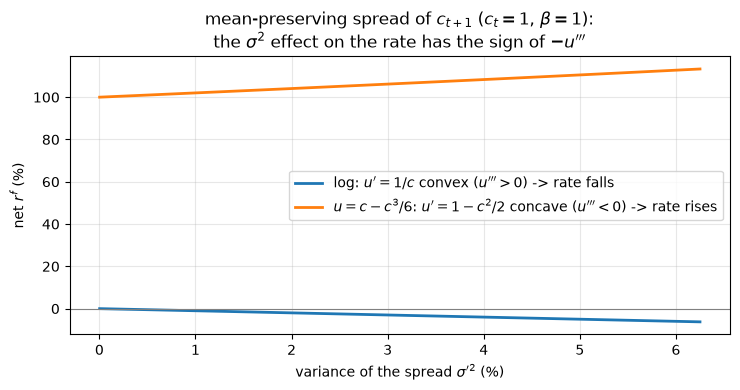

--------------------------------------------------------------------------
u'-curvature test (matches the figure above), r^f = u'(1)/E[u'(c1)] - 1:
  log u' = 1/c,          convex (u'''>0):  r^f(s'=0.1) = -1.0000%   r^f(s'=0.2) = -4.0000%
  u = c - c^3/6, u' concave (u'''<0):  r^f(s'=0.1) = +1.0101%   r^f(s'=0.2) = +4.1667%
-> the precautionary direction of the sigma^2 term needs convex u',
   automatic in the power family (gamma>0) but not implied by concavity.


In [11]:
# Demo 10.2 (the sigma^2 effect has the sign of -u''': opposite rates, same concavity)
sp = np.linspace(0.005, 0.25, 120)
r_log = 1.0 / (0.5 * (1/(1-sp) + 1/(1+sp))) - 1.0      # E[1/c] = 1/(1-s^2): rate falls
r_cub = 1.0 / (1.0 - 0.5 * (1.0 + sp**2)) - 1.0        # E[u'] = (1-s^2)/2: rate rises
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(sp**2 * 100, r_log * 100, lw=2,
        label="log: $u' = 1/c$ convex ($u'''>0$) -> rate falls")
ax.plot(sp**2 * 100, r_cub * 100, lw=2,
        label="$u = c - c^3/6$: $u' = 1-c^2/2$ concave ($u'''<0$) -> rate rises")
ax.axhline(0, color='gray', lw=0.8)
ax.set_xlabel("variance of the spread $\\sigma'^2$ (%)")
ax.set_ylabel("net $r^f$ (%)")
ax.set_title("mean-preserving spread of $c_{t+1}$ ($c_t=1$, $\\beta=1$):\n"
             "the $\\sigma^2$ effect on the rate has the sign of $-u'''$")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

price_line()
print("u'-curvature test (matches the figure above), r^f = u'(1)/E[u'(c1)] - 1:")
for name, up in [("log u' = 1/c,          convex (u'''>0)", lambda c: 1.0 / c),
                 ("u = c - c^3/6, u' concave (u'''<0)", lambda c: 1.0 - c * c / 2.0)]:
  r1 = up(1.0) / (0.5 * (up(0.9) + up(1.1))) - 1.0
  r2 = up(1.0) / (0.5 * (up(0.8) + up(1.2))) - 1.0
  print(f"  {name}:  r^f(s'=0.1) = {r1*100:+.4f}%   r^f(s'=0.2) = {r2*100:+.4f}%")
print("-> the precautionary direction of the sigma^2 term needs convex u',")
print("   automatic in the power family (gamma>0) but not implied by concavity.")

## 11. "An asset's price is lowered if its payoff covaries positively with consumption" (§1.4, Eqn 1.10)

**The reading under test.** As stated: positive covariance between payoff
and consumption lowers the price below the risk-neutral benchmark.

**Verdict:** false; requires additional assumptions, such as
comonotonicity between payoff and consumption (Demos 11.1 and 11.2). The
weak reading "not raised" fails too: sibling B's price is above its
benchmark.

**Math.** The decomposition behind the sentence (Eqns 1.9–1.10):

$$
p = \frac{E(x)}{R^f} + \frac{\operatorname{cov}\big[\beta u'(c_{t+1}),\, x_{t+1}\big]}{u'(c_t)}
  = \frac{E(x)}{R^f} + \operatorname{cov}(m, x).
$$

The **risk-neutral benchmark** $E(x)/R^f = E(x)\,E(m)$ is the price the
payoff would have if $\operatorname{cov}(m,x)$ were zero, i.e. with no
risk adjustment. "Price lowered" means $p = E[mx] < E(x)/R^f$; "raised"
means the reverse. So the sentence needs $\operatorname{cov}(m,x) \le 0$
to follow from $\operatorname{cov}(c_{t+1}, x) > 0$: even if the payoff
covaries positively with consumption, you cannot definitely say that it
covaries negatively with marginal utility. The demos show both outcomes.
The chapter's $m$-space companion sentence is true as stated ("An asset
whose payoff covaries positively with the discount factor has its price
raised and vice versa", §1.4): sibling B of Demo 11.1 has
$\operatorname{cov}(m,x) > 0$ and its price is indeed raised above its
benchmark. The failure is the consumption-to-marginal-utility transfer,
not the $m$-space algebra.

**Demo 11.1: two sibling payoffs.** Log utility, $c_t = 1$, $\beta = 1$,
three equiprobable states with $c_{t+1} = (1,2,3)$, so
$m = 1/c_{t+1} = (1,\ 0.5,\ 0.333)$. Two sibling payoffs with
**identical** $\operatorname{cov}(c_{t+1},x) = +1/3$. The printout
computes both covariances, both prices, and both benchmarks.

In [12]:
# Demo 11.1 (sibling payoffs): identical cov(c1, x), opposite risk adjustments.
# (Local names only: c1 below is the sibling economy's consumption.)
c1s = np.array([1., 2., 3.]); ms = 1.0 / c1s
price_line()
print(f"c_(t+1) = {c1s}   m = 1/c_(t+1) = {np.round(ms, 6)}   E(m) = {E(ms):.6f}")
for name, xs in [('A: x = (3,1,4)', np.array([3., 1., 4.])),
                 ('B: x = (4,1,5)', np.array([4., 1., 5.]))]:
  p, rn = E(ms * xs), E(xs) * E(ms)
  print(f"{name}:  cov(c1,x) = {cov(c1s,xs):+.6f}   cov(m,x) = {cov(ms,xs):+.6f}")
  print(f"          p = E[mx] = {p:.6f}   vs benchmark E(x)/Rf = E(x)*E(m) = {rn:.6f}"
        f"   ->  price {'lowered' if p < rn else 'raised'}")
price_line()
print('Both payoffs have IDENTICAL cov(c,x)=+1/3, so the chapter claim predicts')
print('"price lowered" for both; sibling B shows the opposite instead.')
print('From A to B: +1 payoff in state 1 (m above its mean by 0.389 -> pushes cov(m,x) up),')
print('+1 in state 3 (m below its mean by 0.278 -> pushes it down). 0.389 > 0.278')
print('because u\'=1/c is steep at low consumption, so the state-1 addition wins and')
print('cov(m,x) flips sign. Comonotonicity rules this out: (x_s-x_s\')(m_s-m_s\') <= 0')
print('in every state pair, so cov(m,x) <= 0.')

--------------------------------------------------------------------------
c_(t+1) = [1. 2. 3.]   m = 1/c_(t+1) = [1.       0.5      0.333333]   E(m) = 0.611111
A: x = (3,1,4):  cov(c1,x) = +0.333333   cov(m,x) = -0.018519
          p = E[mx] = 1.611111   vs benchmark E(x)/Rf = E(x)*E(m) = 1.629630   ->  price lowered
B: x = (4,1,5):  cov(c1,x) = +0.333333   cov(m,x) = +0.018519
          p = E[mx] = 2.055556   vs benchmark E(x)/Rf = E(x)*E(m) = 2.037037   ->  price raised
--------------------------------------------------------------------------
Both payoffs have IDENTICAL cov(c,x)=+1/3, so the chapter claim predicts
"price lowered" for both; sibling B shows the opposite instead.
From A to B: +1 payoff in state 1 (m above its mean by 0.389 -> pushes cov(m,x) up),
+1 in state 3 (m below its mean by 0.278 -> pushes it down). 0.389 > 0.278
because u'=1/c is steep at low consumption, so the state-1 addition wins and
cov(m,x) flips sign. Comonotonicity rules this out: (x_s-x_s')(m_s-m_s') 

**Demo 11.2: the same failure inside the chapter's own setting, and the
rescue.** The stripped-down economy of Demo 11.1 held consumption fixed
(no trading margin: the consumption values were simply given).
Here the investor's problem is solved in full: $u = \ln c$, $\beta = 1$,
$p_t = 0.9$, $e_t = 1$, $e_{t+1} = (0.7, 2.2, 3.6)$, payoff $x = (3,-2,4)$.
The optimum is interior and verified (the printout reports $\xi^*$ and
$V'' < 0$), and the chapter's hypothesis
$\operatorname{cov}(x, c_{t+1}) > 0$ holds at the solution. The printout
closes with the rescue: the payoff is replaced with one comonotone with
consumption, $x = (c_{t+1} - c_t) + 1.5$, increasing in $c_{t+1}$ by
construction.

In [13]:
# Demo 11.2 (full log-utility equilibrium + comonotone rescue): the chapter's own
# setting, optimum solved and verified. (solve_ref, from the setup cell, solves the
# economy: u = ln c, beta = 1, p = 0.9, e_(t+1) = (0.7, 2.2, 3.6), x = (3,-2,4).)
e1, x, p, xi, ct, c1, m, Rf, R, x_com, m_com, p_com, rn_com = solve_ref()
Vpp = -p**2/ct**2 - E(x**2/c1**2)
print(f"xi* = {xi:.6f}   V''(xi*) = {Vpp:.4f}  (<0: global max, log)")
print(f"c_t = {ct:.6f}   c_(t+1) = {c1}   (all > 0)")
price_line()
print(f"cov(x, c1)  = {cov(x, c1): .6f}   > 0   ('covaries positively with consumption')")
print(f"cov(m, x)   = {cov(m, x): .6f}   > 0   (risk adjustment raises price)")
print(f"p           = {p:.6f}   >   E(x)/Rf = {E(x)*E(m):.6f}   ->  price raised")

print(f"\nrescue (log + comonotone x = (c1-c_t)+1.5): cov(m,x)={cov(m_com, x_com):+.6f} -> "
      f"p={p_com:.6f} {'<' if p_com < rn_com else '>'} E(x)/Rf={rn_com:.6f}  (price {'lowered' if p_com < rn_com else 'raised'})")

xi* = 0.102376   V''(xi*) = -4.6071  (<0: global max, log)
c_t = 0.907862   c_(t+1) = [1.007127 1.995249 4.009502]   (all > 0)
--------------------------------------------------------------------------
cov(x, c1)  =  1.127476   > 0   ('covaries positively with consumption')
cov(m, x)   =  0.020624   > 0   (risk adjustment raises price)
p           = 0.900000   >   E(x)/Rf = 0.879376   ->  price raised

rescue (log + comonotone x = (c1-c_t)+1.5): cov(m,x)=-0.325354 -> p=1.220289 < E(x)/Rf=1.545643  (price lowered)


**Intuition: comonotonicity.** There are a number of ways to ensure
$\operatorname{cov}(m,x) \le 0$. Assuming comonotonicity between the
payoff $x$ and consumption $c_{t+1}$ is one way to do this. A payoff is
**comonotone** with consumption if the two are similarly ordered in every
state: for any two states $s, s'$, if $x_s > x_{s'}$ then
$c_s \ge c_{s'}$ (equivalently, the payoff is an increasing function of
consumption). Since concave $u$ makes $m$ a decreasing function of
consumption, a payoff comonotone with $c_{t+1}$ is oppositely ordered
with $m$: in every pair of states the higher-payoff state has the lower
$m$, which forces $\operatorname{cov}(m,x) \le 0$ and the
price at or below the benchmark, the chapter's conclusion, now validly
derived. Is comonotonicity the exact requirement? No: it is sufficient,
not necessary. The exact requirement is $\operatorname{cov}(m,x) \le 0$
itself. Comonotonicity is the clean statewise condition that forces that
sign for every concave $u$ at once, with no computation. Individual
payoffs can land on $\operatorname{cov}(m,x) \le 0$ without being
comonotone (sibling A is one: $x = (3,1,4)$ is not comonotone with
$c_{t+1} = (1,2,3)$, since state 2 has middling consumption but the lowest
payoff, and still has $\operatorname{cov}(m,x) < 0$). The value of the
comonotonicity assumption is robustness: one checkable hypothesis that
rules out the bad
orderings in a single stroke, and it is the missing hypothesis the chapter
would have to add.

**How restrictive is comonotonicity?** Very. A comonotone payoff is an
increasing function of consumption, so buying it means buying an asset
that tracks your own consumption level: it pays out more
precisely in the states where you are already consuming more. Few real
assets look like that from any one investor's point of view (a claim on
aggregate consumption comes closest, and only if your consumption moves
one-for-one with it). The restriction only gets stronger as the state
space grows. With multi-dimensional inputs, a comonotone function must
preserve the relative ordering of *all* outputs at once, so on a vector
or function-valued consumption stream comonotonicity leaves only one
degree of freedom: stretching or squashing the amplitude of the output.
Any cross-state reshaping, any hedge that pays off in a subset of states,
breaks the ordering and falls outside the assumption. So comonotonicity
makes the claim true only by confining it to tracking assets, a narrow and
unattractive set of payoffs for which the risk adjustment was never in
doubt to begin with. If that is the only repair available, the original
sentence tells us very little.

**Scope: the continuous-time version of the sentence does not fail.**
Section 1.5 (Eqn 1.38) states the same sentence in continuous time: assets
whose returns covary more strongly with consumption get higher mean excess
returns, with constant $\gamma$. There the book is right. With
$\Lambda_t = e^{-\delta t}u'(c_t)$, Itô's lemma (the chain rule of
stochastic calculus) gives
$d\Lambda/\Lambda = -\delta\,dt - \gamma\,dc/c + (\eta/2)\,(dc/c)^2$, and
the quadratic term contributes nothing to the covariance with the return
at leading order: its product with $dp/p$ is of order $dt^{3/2}$,
negligible next to the covariance term of order $dt$. To leading order
$\operatorname{cov}(m, R) = -\gamma\,\operatorname{cov}(\Delta\ln c, R)
+ o(dt)$ (a remainder vanishing faster than $dt$), so positive consumption
covariance does force a positive
premium. The failures above are discrete-time, finite-cross-moment
phenomena; the Taylor step inside Eqns 1.13 and 1.16 is unsafe in finite
samples and safe in the continuous-time limit. (The $\eta$ term is the
third-derivative quantity of section 10; it moves rates, not covariances.)

**Conclusion.** As stated, false: Demo 11.1's printout shows
identical consumption-covariance with opposite risk adjustments, and Demo
11.2's printout shows the same failure at a verified interior optimum
under the chapter's own concavity. With comonotonicity added, true: the
rescue rows price the comonotone payoff below its benchmark, as the
chapter's sentence predicts. Sections 12 and 15 show that the return and beta versions of this sentence fail the same way.

## 12. "Assets whose returns covary positively with consumption make consumption more volatile, and so must promise higher expected returns to induce investors to hold them" (§1.4, Eqns 1.12–1.13)

**The reading under test.** The return version of section 11's sentence:
with the price normalized to one, the payoff $x$ becomes the return
$R = x/p$, and the claim is that positive covariance with consumption earns
a premium over the risk-free rate.

**Verdict:** false; requires additional assumptions, such as
comonotonicity between return and consumption (Demo 12.1).

**Math.** The return form of the pricing equation (Eqns 1.12–1.13):

$$
E(R^i) - R^f = -R^f\,\operatorname{cov}(m, R^i)
= -\,\frac{\operatorname{cov}\big[u'(c_{t+1}),\, R^i_{t+1}\big]}{E\big[u'(c_{t+1})\big]}.
$$

So "promises a higher expected return" means
$\operatorname{cov}(m,R) \le 0$: exactly the transfer tested in section 11,
with the payoff replaced by the return. Even if the return covaries
positively with consumption, you cannot definitely say that it covaries
negatively with marginal utility. The economy is deliberately minimal: one
asset and no traded risk-free security, so $R^f = 1/E(m)$ is the book's
shadow risk-free rate ("If a risk-free security is not traded, we can
define Rf = 1/E(m) as the 'shadow' risk-free rate", §1.4).

**Demo 12.1: the solved economy of section 11, read in return space.** The
printout reports the return $R = x/p$ of section 11's Demo 11.2 asset, its
covariance with consumption, and its exact premium; the last line prices
the comonotone rescue payoff of section 11's Demo 11.2 in return space.

In [14]:
# Demo 12.1 (return version): the same solved economy as Demo 11.2, read in return
# space. (solve_ref re-solves Demo 11.2's economy here, so the section runs on its own.)
e1, x, p, xi, ct, c1, m, Rf, R, x_com, m_com, p_com, rn_com = solve_ref()
R_com = x_com / p_com
price_line()
print(f"R = x/p = {np.round(R, 6)}")
print(f"cov(R, c1)  = {cov(R, c1): .6f}  (>0: covaries positively with consumption)")
print(f"E(R) - Rf   = {E(R)-Rf: .6f}  (<0: underperforms the risk-free rate)")
print(f"\nrescue (comonotone payoff of section 11's Demo 11.2, return space): "
      f"E(R_com) - Rf = {E(R_com) - Rf:+.6f}  (>0: earns the premium)")
print("-> a return covarying positively with consumption underperforms;")
print("   comonotonicity repairs the sign.")

--------------------------------------------------------------------------
R = x/p = [ 3.333333 -2.222222  4.444444]
cov(R, c1)  =  1.252751  (>0: covaries positively with consumption)
E(R) - Rf   = -0.043431  (<0: underperforms the risk-free rate)

rescue (comonotone payoff of section 11's Demo 11.2, return space): E(R_com) - Rf = +0.505321  (>0: earns the premium)
-> a return covarying positively with consumption underperforms;
   comonotonicity repairs the sign.


**Intuition.** The intuition of this section matches section 11's:
pricing runs through $\operatorname{cov}(m,R)$, not through
$\operatorname{cov}(c,R)$, and consumption-covariance does not control the
sign of $\operatorname{cov}(m,R)$ without comonotonicity. A return can
covary positively with consumption and still be concentrated in payoff
where $m$ is high, which is what the printout's rescue row rules out: the
comonotone return earns the premium, as the sentence predicts. Read
"higher" weakly, as "at least the risk-free rate": the printout shows the
premium is negative, so even the weak reading fails.

## 13. "Idiosyncratic risk, uncorrelated with the discount factor, generates no premium" (§1.4)

**The reading under test.** The chapter's $m$-space sentence: risk
uncorrelated with the discount factor generates no premium; if
$\operatorname{cov}(m,x) = 0$ then $p = E(x)/R^f$ "no matter how large
$\sigma^2(x)$".

**Verdict:** true as stated; no demo is needed.

**Math.** $p = E[mx] = E[m]\,E(x) +
\operatorname{cov}(m,x)$, so $\operatorname{cov}(m,x) = 0$ gives
$p = E(x)/R^f$ exactly: pure algebra, verified in the projection row of
section 3's identity checks.

## 14. "Risk corrections to asset prices should be driven by the covariance of asset payoffs with marginal utility and hence by the covariance of asset payoffs with consumption" (chapter introduction, p. 5)

**The reading under test.** The chapter's introductory sentence, stated
before any equation. Its first half is exact algebra: the risk adjustment
is $\operatorname{cov}(m, x)$ (Eqn 1.9). The "hence" is a transfer: it
claims that the covariance with consumption drives the risk correction,
because marginal utility moves oppositely to consumption.

**Verdict:** false as stated; the "hence" requires additional assumptions,
such as comonotonicity between payoff and consumption (section 11's
finding): consumption-covariance does not pin the risk correction (Demo
14.1: a payoff with $\operatorname{cov}(c_{t+1},x) = 0$ exactly has
$\operatorname{cov}(m,x) > 0$ and its price is raised).

**Demo 14.1: the test.** The sibling economy of section 11
($c_{t+1} = (1,2,3)$, log, $\beta = 1$, $m = (1, 0.5, 0.333)$): the payoff
$x = (1,0,1)$ has $\operatorname{cov}(c_{t+1},x) = 0$ exactly, yet the
printout shows $\operatorname{cov}(m,x) > 0$ and the price above the
benchmark: the price is raised. The printout also prices the residual
$\varepsilon = (-1, 1, 1.5)$: orthogonal to $m$ in the pricing sense
($E[m\varepsilon] = 0$, price zero) but
$\operatorname{cov}(c_{t+1},\varepsilon) \ne 0$.

In [15]:
# Demo 14.1 (idiosyncratic risk): uncorrelated with consumption does NOT mean
# uncorrelated with m. (Local names only: c1 below is the sibling economy's
# consumption, not the solved economy's.)
c1s = np.array([1., 2., 3.]); ms = 1.0 / c1s
xs = np.array([1., 0., 1.])
eps = np.array([-1., 1., 1.5])
price_line()
print(f"x = (1,0,1):     cov(c1,x) = {cov(c1s,xs): .6f} (=0)   cov(m,x) = {cov(ms,xs): .6f} (>0)")
print(f"                 p = E[mx] = {E(ms*xs):.6f}  >  E(x)/Rf = {E(xs)*E(ms):.6f}  ->  price raised")
print(f"eps = (-1,1,1.5): E[m*eps] = {E(ms*eps): .2e} (price 0)   cov(c1,eps) = {cov(c1s,eps): .6f} (<>0)")
print("-> 'idiosyncratic' must mean uncorrelated with m, not with consumption;")
print("   pricing runs through cov(m,x), not through the variance of consumption.")

--------------------------------------------------------------------------
x = (1,0,1):     cov(c1,x) =  0.000000 (=0)   cov(m,x) =  0.037037 (>0)
                 p = E[mx] = 0.444444  >  E(x)/Rf = 0.407407  ->  price raised
eps = (-1,1,1.5): E[m*eps] =  0.00e+00 (price 0)   cov(c1,eps) =  0.833333 (<>0)
-> 'idiosyncratic' must mean uncorrelated with m, not with consumption;
   pricing runs through cov(m,x), not through the variance of consumption.


**Intuition.** The intuition here matches section 11's: pricing runs
through $\operatorname{cov}(m,x)$, not through the variance of
consumption. "Idiosyncratic" in the pricing equation means uncorrelated
with the discount factor; a payoff can be uncorrelated with consumption
in every state and still be concentrated where $m$ is high (state 1
above), which is exactly what raises its price.

## 15. "Expected returns should increase linearly with their betas on consumption growth itself" (§1.4, Eqn 1.16)

**The reading under test.** Eqn 1.16 of the chapter, read as: higher
consumption beta, higher expected return, with a positive price of risk
$\lambda_{\Delta c} = \gamma\,\operatorname{var}(\Delta c_{t+1})$, where
$\beta_{i,\Delta c}$ is the consumption beta (the regression coefficient
of the return on consumption growth $\Delta c_{t+1} = c_{t+1} - c_t$).

**Verdict:** false; requires additional assumptions, such as
comonotonicity between return and consumption (Demo 15.1).

**Math.** Taylor-expanding the return equation in consumption growth
gives

$$
E(R^i) = R^f + \beta_{i,\Delta c}\,\lambda_{\Delta c},
\qquad \lambda_{\Delta c} = \gamma\,\operatorname{var}(\Delta c_{t+1}).
$$

The Taylor step behind Eqn 1.16 replaces
$\operatorname{cov}(m, R)$ with $-\gamma\operatorname{cov}(\Delta c, R)$.
That replacement silently assumes the return is comonotone with
consumption, the ordering hypothesis of exactly the kind section 11 found
missing. Without it, positive consumption beta does not force a positive
premium.

**Demo 15.1: the same economy, read in beta space.** The printout reports the
consumption beta of section 12's return, the premium Eqn 1.16 predicts from
it, and the exact premium; the last line reports the comonotone rescue
payoff's beta and premium.

In [16]:
# Demo 15.1 (beta version): Demo 11.2's solved economy, read in beta space.
# (solve_ref re-solves it here so the section runs on its own; R_com is the
# comonotone rescue payoff's return, as in Demo 12.1.)
e1, x, p, xi, ct, c1, m, Rf, R, x_com, m_com, p_com, rn_com = solve_ref()
R_com = x_com / p_com
bR = cov(R, c1 - ct) / cov(c1 - ct, c1 - ct)     # consumption beta of the return
lam = bR * cov(c1 - ct, c1 - ct)                 # Eqn 1.16's predicted premium = beta*lambda; lambda = gamma*var(dc), gamma = 1 (log) here
price_line()
print(f"consumption beta_(R,dc) = {bR: .6f}  (>0)")
print(f"Eqn 1.16 predicts a premium of +{lam: .6f}; the exact premium is {E(R)-Rf: .6f}: sign wrong.")
print(f"rescue (comonotone payoff of section 11's Demo 11.2): beta = "
      f"{cov(R_com, c1-ct)/cov(c1-ct, c1-ct): .6f}  (>0),  exact premium {E(R_com)-Rf:+.6f}  (>0)")
print("-> positive consumption beta does not force a positive premium without the")
print("   ordering hypothesis; with comonotonicity both the beta and the premium are positive.")

--------------------------------------------------------------------------
consumption beta_(R,dc) =  0.802596  (>0)
Eqn 1.16 predicts a premium of + 1.252751; the exact premium is -0.043431: sign wrong.
rescue (comonotone payoff of section 11's Demo 11.2): beta =  0.819478  (>0),  exact premium +0.505321  (>0)
-> positive consumption beta does not force a positive premium without the
   ordering hypothesis; with comonotonicity both the beta and the premium are positive.


**Intuition.** The intuition of this section matches sections 11 and 12:
the sign transfer from consumption covariance to marginal-utility
covariance fails without comonotonicity, in beta space as in price space.
The Taylor step hides exactly the hypothesis that fails; adding it
(comonotone return) makes both the beta and the premium positive, as the
sentence predicts. Read "increase" weakly, as "weakly increasing in the
beta": a return with zero consumption beta prices at exactly $R^f$, and
the printout's positive-beta return prices below $R^f$, so even the weak
reading fails.

## 16. Upper-frontier returns "are 'maximally risky' and thus get the highest expected returns" (§1.4, Eqns 1.17–1.18)

**The reading under test.** The chapter's frontier reading (its point 2):
"Returns on the upper part of the frontier are perfectly negatively
correlated with the discount factor and hence positively correlated with
consumption. They are 'maximally risky' and thus get the highest expected
returns." Read without qualification, "the highest expected returns" would
compare returns at different volatilities, where the upper frontier's mean
rises with $\sigma(R)$; the defensible reading, tested here, is "highest
expected return at their volatility level".

**Verdict:** true; no additional assumptions needed: only the correlation
bound $|\rho| \le 1$ enters, so it holds for any discount factor $m$
(Demo 18.1).

**Math.** With $|\rho| \le 1$ the largest mean at given $\sigma(R)$ is at
$\rho = -1$, attained by the price-1 return $R^{up} = a - m$ with
$a = \frac{1+E[m^2]}{E[m]}$, the equality case of Eqn 1.17: any return
off the upper frontier has a lower mean at the same volatility. Demo 18.1
verifies the equality properties (price 1, $\rho(m, R^{up}) = -1$) in the
solved economy of section 11.

## 17. Upper-frontier returns are "perfectly negatively correlated with the discount factor and hence positively correlated with consumption" (§1.4, Eqns 1.17–1.18)

**The reading under test.** The second half of the chapter's frontier
reading: the returns that attain the upper frontier are the ones
positively correlated with consumption ("maximally risky").

**Verdict:** true; no additional assumptions needed (Demo 18.1 verifies
the sign numerically).

**Math.** The upper-frontier return $R^{up} = a - m$ is a *decreasing*
function of $m$, and $m = \beta\,u'(c_{t+1})/u'(c_t)$ is decreasing in
$c_{t+1}$ because concave $u$ makes $u'$ decreasing: so $R^{up}$ is
increasing in consumption, hence positively correlated with it, under
exactly the book's stated assumptions. Demo 18.1's last row checks
$\operatorname{cov}(R^{up}, c_{t+1}) > 0$ in the solved economy of
section 11.

## 18. "The slope of the mean-standard deviation frontier is higher if the economy is riskier—if consumption is more volatile—or if investors are more risk averse" (§1.4, Eqns 1.19–1.20)

**The reading under test.** The chapter's reading of the Sharpe-ratio
bound: the slope of the mean-standard deviation frontier, the largest
available Sharpe ratio (excess expected return over the risk-free rate,
per unit of volatility), rises with consumption volatility and with risk
aversion.

**Verdict:** true; no additional assumptions needed.

**Math.** The slope is $\sigma(m)/E(m)$: the frontier form of Eqn 1.18,
with the bound of Eqn 1.17 attained on the upper frontier. In the
two-point lognormal family of section 9 ($\Delta\ln c \in \{\mu-\sigma,
\mu+\sigma\}$, power utility), $m = e^{-\delta}e^{-\gamma\Delta\ln c}$
takes two values, so the slope has a closed form:
$\sigma(m)/E(m) = \tanh(\gamma\sigma)$ (the hyperbolic tangent),
increasing in $\gamma$ and in
$\sigma$ exactly. The book's lognormal formula
$\sqrt{e^{\gamma^2\sigma^2} - 1}$ (Eqn 1.20) is increasing in both for the
same reason. Demo 18.1 evaluates the slope in the family and verifies the
equality-case return $R^{up} = a - m$ of section 16: price 1,
$\rho(m, R^{up}) = -1$, and positively correlated with consumption,
section 17's claim.

In [17]:
# Demo 18.1 (frontier slope): slope = sigma(m)/E(m) in the two-point lognormal
# family (exact tanh(gamma*sigma)); and the equality return R^up = a - m on
# Demo 11.2's solved economy (re-solved here so the section runs on its own):
# price 1, rho(m, R^up) = -1, cov(R^up, c1) > 0.
w2 = np.array([0.5, 0.5])
E2 = lambda a: float(np.dot(w2, a))

price_line()
print("frontier slope sigma(m)/E(m), two-point lognormal family (mu = 2%, delta = 1%):")
for g, s in [(1, 0.01), (2, 0.01), (2, 0.03)]:
  m2 = np.exp(-0.01) * np.exp(-g * np.array([0.02 - s, 0.02 + s]))
  sl = np.sqrt(E2(m2 * m2) - E2(m2)**2) / E2(m2)
  print(f"  gamma={g}, sigma={s*100:.0f}%:  slope = {sl:.6f}   tanh(g*sigma) = {np.tanh(g*s):.6f}")
print("book's lognormal formula sqrt(e^(g^2 s^2) - 1) at (gamma, sigma) = (2, 1%): "
      f"{np.sqrt(np.exp(4*0.01**2) - 1):.6f}")
print("-> the slope rises with gamma (risk aversion) and with sigma (risk), as the sentence says")

price_line()
e1, x, p, xi, ct, c1, m, Rf, R, x_com, m_com, p_com, rn_com = solve_ref()
a_up = (1 + E(m * m)) / E(m)                  # equality return of section 16, on section 11's economy
Rup = a_up - m
rho_up = cov(m, Rup) / (np.sqrt(cov(m, m)) * np.sqrt(cov(Rup, Rup)))
print("equality return R^up = a - m (section 11's solved economy):")
print(f"  price E[m R^up] = {E(m * Rup):.8f}   (target 1)")
print(f"  rho(m, R^up)    = {rho_up: .6f}   (target -1)")
print(f"  cov(R^up, c1)   = {cov(Rup, c1): .6f}   (>0: positively correlated with consumption, section 17)")

--------------------------------------------------------------------------
frontier slope sigma(m)/E(m), two-point lognormal family (mu = 2%, delta = 1%):
  gamma=1, sigma=1%:  slope = 0.010000   tanh(g*sigma) = 0.010000
  gamma=2, sigma=1%:  slope = 0.019997   tanh(g*sigma) = 0.019997
  gamma=2, sigma=3%:  slope = 0.059928   tanh(g*sigma) = 0.059928
book's lognormal formula sqrt(e^(g^2 s^2) - 1) at (gamma, sigma) = (2, 1%): 0.020002
-> the slope rises with gamma (risk aversion) and with sigma (risk), as the sentence says
--------------------------------------------------------------------------
equality return R^up = a - m (section 11's solved economy):
  price E[m R^up] = 1.00000000   (target 1)
  rho(m, R^up)    = -1.000000   (target -1)
  cov(R^up, c1)   =  0.325354   (>0: positively correlated with consumption, section 17)


## 19. "Assets whose dividend streams covary negatively with marginal utility, and positively with consumption, have lower prices" (§1.4, p. 27)

**The reading under test.** The chapter's present-value sentence, stated
after the stream decomposition of Eqn 1.23: a dividend stream whose
payoffs covary negatively with marginal utility, and positively with
consumption, has a price below the sum of its risk-neutral terms.

**Verdict:** true; no additional assumptions needed. The premise names the
marginal-utility covariance itself, so each term's risk adjustment
$\operatorname{cov}_t(d_{t+j},\, m_{t+j})$ is negative by assumption, and
each term sits below its benchmark $E_t[d_{t+j}]/R^f_{t+j}$.

**Math.** The book's stream decomposition,

$$
p = \sum_{j=1}^{\infty} \frac{E_t[d_{t+j}]}{R^f_{t+j}}
  + \sum_{j=1}^{\infty} \operatorname{cov}_t(d_{t+j},\, m_{t+j}),
$$

is the one-period decomposition of section 3 (Eqn 1.9) applied term by
term; the Eqn 1.9 row of section 3's identity checks is the $j = 1$ case.
Given the premise, every covariance term is negative and the conclusion
follows; no demo is needed. The contrast with section 11 is the point: the
one-period sentence drops the marginal-utility covariance from its premise
and keeps only the consumption clause, which is why it fails; the stream
sentence keeps both halves, which is why it is true as stated.

Sibling scripts: `counterexample_search.py` (experiments 1–8, print-only) and
`doc_numbers.py` (exact values quoted in the companion paper
`counterexamples_v3.md`).